In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':14})
import json as js
import os

In [12]:
path = '/albedo/home/jgaertne/veros/'

In [5]:
lst = os.listdir(path)
files =  [s for s in lst if 'bm_' in s]
files.sort()

files.remove('bm_10e5_jax')
files.remove('bm_10e5_jax_n1')
files.remove('bm_10e5_jax_t10')
files

['bm_10e3_jax.json',
 'bm_10e3_jaxgpu.json',
 'bm_10e3_jaxmpi.json',
 'bm_10e3_np.json',
 'bm_10e3_npmpi.json',
 'bm_10e4_jax.json',
 'bm_10e4_jaxgpu.json',
 'bm_10e4_jaxmpi.json',
 'bm_10e4_np.json',
 'bm_10e4_npmpi.json',
 'bm_10e5_jaxgpu.json',
 'bm_10e5_jaxmpi.json',
 'bm_10e5_npmpi.json',
 'bm_10e6_jaxgpu.json',
 'bm_10e6_jaxmpi.json',
 'bm_10e6_npmpi.json']

In [35]:
[t_n, t_nm, t_j, t_jm, t_jg] = [[] for _ in range(5)]

for file in files:
    backend = file.split('.')[0].split('_')[-1]
    
    f = open(path+file)
    data = js.load(f)
    f.close()
    
    time = data['benchmarks']['veris_dyn_benchmark.py'][0]['per_iteration']['mean'],

    if backend=='np': t_n += time
    elif backend=='npmpi': t_nm += time
    elif backend=='jax': t_j += time
    elif backend=='jaxmpi': t_jm += time
    elif backend=='jaxgpu': t_jg += time    

In [36]:
size = [10**i for i in range(3,7)]

Text(0, 0.5, 'mean time per iteration /s')

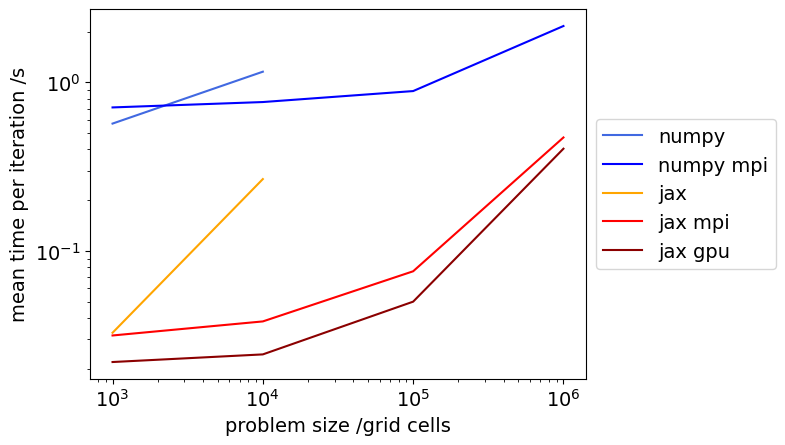

In [45]:
fig = plt.figure()
ax = fig.add_subplot()
for data, label, color in zip([t_n,t_nm,t_j,t_jm,t_jg],
                       ['numpy','numpy mpi','jax','jax mpi','jax gpu'],
                       ['royalblue','blue','orange','red','darkred']):
    ax.plot(size[:len(data)],data,label=label,color=color)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('problem size /grid cells')
ax.set_ylabel('mean time per iteration /s')